# Distance Metric Analysis: Hamming vs Edit Distance for CRISPR Spacer Detection

## Overview

This notebook quantifies how distance metric choice affects background (non-planned) alignment rates using simulated CRISPR spacer data with ground truth; historically these non-planned alignments were called non-planned matches.
- **Hamming Distance** (≤N): Substitutions only, no indels allowed
- **Edit Distance** (≤N): Substitutions + indels allowed

We use the `compare-results` command which implements:
- **Coordinate tolerance matching** (5bp default) to handle slight boundary differences (e.g., placing a gap instead of a substitution in the terminal region of an alignment)
- **Verification**: All reported alignments (including those not in the ground truth) are verified by extracting the reference region and aligning to the reported spacer sequence
- **Classification into three categories**:
  - `positive_in_plan`: Matches ground truth (true positives)
  - `positive_not_in_plan`: Valid alignment NOT in ground truth (background/chance matches, or real matches when no GT exists)
  - `invalid_alignment`: **True False Positives** - failed verification (exceeds distance threshold)
- **Augmented metrics**: For simulated runs, adjusts metrics to include verified non-planned alignments as true positives

## Important Terminology:

**What are "False Positives" in this analysis?**
- **Invalid alignments** = True false positives (alignments that fail validation - the distance measured is larger than the accepted threshold). Note, some tools don't really let us control setting a threshold, so some level of these is accepted.
- **Positives not in plan** ≠ False positives! These are:
  - Valid alignments that arise by chance (background matches)
  - Real biological matches (when there is no ground truth, e.g. real meta/genomes vs real spacers)
  - We mostly **ignore invalid alignments** in these plots and focus on background (non-planned) alignment rates. Main reason is that not all tools allow strict control over distance thresholds, so invalid alignments may be present due to tool's varying control over reporting setting - for example, with blastn, we can't hard-set a max edit/hamming distance, the closest we can do is set a min percent identity and min query (spacer) coverage, which allow a range of distances to be reported, and this range may exceed our desired threshold in order to capture all valid matches (for example, a 85% identity, over at least 80% of the spacer, will allow for 3 distance for a spacer of length 20 (20 * 0.15 ), but will allow more for a spacer of length 30 (30 * 0.15 = 4.5) [[[note that the length also matters - the %id is out of the aligned region, hence the qcoverage setting being so high]]]). In this example, if we use the code here and in compare_results.py to validate the alignments at 3 distance, those blastn alignments with distance 4 or 5 will be marked as invalid alignments, but that doesn't mean blastn did something wrong.
- **"*_Augemented"** = performance metrics that include all verified non-planned alignments (within allowed distance) as true positives.


**Metrics:**
- **TP_planned**: Planned spacers correctly identified
- **GT_planned**: Simulated ground truth (where/how we inserted spacers)
- **All_TP**: TP_planned + verified non-planned
- **GT_augmented**: GT_planned + verified non-planned
- **Invalid alignments**: Alignments that failed verification (true FPs)

**Performance Metrics:**
- **Precision (planned)**: TP_planned / (TP_planned + all non-TP)
- **Recall (planned)**: TP_planned / GT_planned
- **Precision (augmented)**: All_TP / (All_TP + invalid_alignments)
- **Recall (augmented)**: All_TP / GT_augmented
- **Non-planned Rate**: `positives_not_in_plan / all_true_positives × 100` - not useful! this is dependent on how many planned insertions we made, and we control that value.
- **Invalid Rate**: `invalid_alignments / (all_alignments) × 100`  - "True" false positive rate, **however**, in many tools we can't strictly control the reporting to be exactly within our desired metric and value - hence this rate doesn't really indicate a tool is "wrong" or "bad", just that we couldn't strictly control it at command exec time.  
- **Background Frequency**: Expected number of non-planned matches, per a given search size: either for every n spacers searched in m contigs, or per n spacer-bp searched in m contig-bp (i.e. total length for each spacer searched, combined). This is a more useful metric, as it is independent of how many planned insertions we made). Apart from the simulations variables, this value is dependent on the distance metric used, the search space size, and threshold allowed.  

**Coordinate Tolerance Matching**: 
   - up to 5bp tolerance for alignments region -the slight boundary differences reduce the "double-counting" of e.g. a hit indel vs substitution placement on terminal ends.
   - Example: tool reports 5000-5036 (with 1 insertion) vs ground truth 5001-5036 (with 1 mismatch) → the hit with insertion is: verified (within the edit/hamming of up to 1 for the region in front of the spacer), and then counted as a 1 planned ground truth entry.   


**Reminder**: these analyses use a tool-independent aggreaget `all_tools_combined`, which merges unique alignments from all tools (allowing some coordinate tolerance for boundary differences).and validates each alignment. This avoids double-counting and provides accurate background alignment rates.
This might decrease the total count of hamming compared to edit - as traditionally, hamming is expected to be of two strings of equal length. By allowing this small terminal ambiguity we kind of break that assumption. In the backend, in the validation step for these strings for hamming up to n, we pad the shorter sequence with `@` (a non IUPAC char, nothing aligns to it) (one time padding the aligned region from the right and one time from the left, then selecting the padded version with lowest hamming value), to make the lengths equal. In reality, a pure hamming distance based tool might still report these variations, if they are within the allowed threshold. For an edit/indel-allowing tool, non-equal lengths are a non-issue - and they may sometime "miss" (not report) the truncated version of the aligned region, if they can open a small gap that would allow a perfect match within the allowed edit distance. In this case, that reported alignment would be counted as a planned match if it overlaps the ground truth region within the coordinate tolerance, and the edit distance is within the allowed threshold. 
For example:
```bash
(benchy) [uneri@ln008 spacer_bench]$ grep "1c47e31b_spacer_10034" results/simulated/ns_100000_nc_10000/raw_outputs/*tsv |  grep "1c47e31b_contig_1828"
#                                                                            qaccver               saccver            nident length mismatch   qlen  gapopen qstart    qend   sstart   send    evalue      bitscore
results/simulated/ns_100000_nc_10000/raw_outputs/blastn_output.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    34      34      0       35      0       1       34      5036    5003    5.27e-11       67.9

#                                                                                 query         ,target,              nident,alnlen,mismatch,qlen  ,gapopen, qstart,  qend,   tstart,  tend,  evalue,         bits
results/simulated/ns_100000_nc_10000/raw_outputs/mmseqs_output.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    34      35      1       35      0       35      1       5002    5036    1.550E-10      60

#                                                                       pat_id          text_id               cost    strand    start   end       match_region                           cigar
results/simulated/ns_100000_nc_10000/raw_outputs/sassy.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    1       -       5000    5036    AGTCTGGGCAGATGTGTCGACCGTTGTCTGACCGTG    34=1I1=


(benchy) [uneri@ln008 spacer_bench]$ grep "1c47e31b_spacer_10034" results/simulated/ns_100000_nc_10000/simulated_data/planned_ground_truth.tsv  | grep "1c47e31b_contig_1828"
# spacer_id              contig_id              start   end     strand  mismatches
1c47e31b_spacer_10034   1c47e31b_contig_1828    5001    5036    true    1
```


## *Update*: Tool-Independent Metrics

Previously (preprint versions) we handled aggregating tool results in these notebooks. Now the `compare-results` command creates a "fake" tool entry called `all_tools_combined` which is the union of all tool results -- contains all unique alignments (or regions) across tools using the existing coordinate tolerance and validation logic. This notebook now uses that tool-independent aggregate, which eliminates some issues. Notably this fixes a double-counting issue regarding the legacy "validated non-planned" matches.

**Background Frequency Metrics** (independent of planned insertion count):
We focus on background match **frequency** given the search space, not compared to the planned ground truth (planned occurrences) which we control. As long as the planned spacers don't occupy a majority of the contig sequence (<1%), the planned rate is completely set by us (`spacer_bencher simulate --spacer-insertions nnn`) and independent from the non-planned rate.

**NEW in V2**: Uses the efficient multi-metric workflow:
1. Runs `compare-results --multi-metric` ONCE per dataset (generates all 3 metrics)
2. Loads `multi_metric_distances.parquet` file
3. Filters by threshold in memory for analysis


In [157]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')

import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import subprocess
from pathlib import Path
import glob

# Configuration
MAX_MISMATCHES = 5  # Maximum threshold for validation
THRESHOLDS = list(range(0, MAX_MISMATCHES + 1))  # Analyze all thresholds 0-5

# Threshold labels with ≤ notation
THRESHOLD_LABELS = [f"≤{t}" for t in THRESHOLDS]

print(f"Analyzing thresholds: {', '.join(THRESHOLD_LABELS)}")
print(f"Configuration: Max mismatches = {MAX_MISMATCHES}")

Analyzing thresholds: ≤0, ≤1, ≤2, ≤3, ≤4, ≤5
Configuration: Max mismatches = 5


In [158]:
def ensure_multi_metric_file(sim_dir: Path, force_regenerate: bool = False) -> Path:
    """
    Ensure the multi-metric parquet file exists for a simulation.
    
    If the file doesn't exist or force_regenerate is True, runs compare-results 
    with --multi-metric to generate it. This runs the validation ONCE for all metrics.
    
    Returns the path to the multi_metric_distances.parquet file.
    """
    mm_file = sim_dir / f"multi_metric_distances.parquet"
    
    if mm_file.exists() and not force_regenerate:
        print(f"✓ Multi-metric file exists: {mm_file.name}")
        return mm_file
    
    print(f"Generating multi-metric file for {sim_dir.name}...")
    
    # Create logs directory
    logs_dir = sim_dir / "logs"
    logs_dir.mkdir(exist_ok=True)
    
    # Build command
    cmd = [
        "pixi", "run", "compare-results",
        str(sim_dir),
        "-m", str(MAX_MISMATCHES),
        "--multi-metric",
        "--multi-metric-output", str(mm_file),
        "--logfile", str(logs_dir / f"compare_results_mm{MAX_MISMATCHES}.log")
    ]
    
    # Run the command
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"ERROR: compare-results failed for {sim_dir.name}")
        print(result.stderr)
        raise RuntimeError(f"compare-results failed with code {result.returncode}")
    
    if not mm_file.exists():
        raise FileNotFoundError(f"Expected {mm_file} was not created")
    
    print(f"✓ Generated: {mm_file.name}")
    return mm_file


def calculate_metrics_from_parquet(
    parquet_path: Path,
    threshold: int,
    metric: str = "hamming"
) -> dict:
    """
    Load multi-metric parquet and calculate metrics for a specific threshold.
    
    This filters the parquet file by threshold instead of re-running validation,
    which is much more efficient.
    
    Args:
        parquet_path: Path to multi_metric_distances.parquet
        threshold: Distance threshold to filter by
        metric: Which distance metric to use ('hamming', 'edit', or 'gap_affine')
    
    Returns:
        Dictionary with metrics:
        - n_tp: True positives (positive_in_plan)
        - n_non_planned: Non-planned alignments (positive_not_in_plan)
        - n_invalid: Invalid alignments
        - non_planned_rate: Percentage of non-planned among all positives
        - invalid_rate: Percentage of invalid among all alignments
    """
    # Load parquet
    df = pl.read_parquet(parquet_path)
    
    # Get the appropriate distance column
    distance_col = f"distance_{metric}"
    if distance_col not in df.columns:
        raise ValueError(f"Distance metric '{metric}' not found in parquet. Available: {df.columns}")
    
    # Filter to all_tools_combined and threshold
    filtered = df.filter(
        (pl.col("tools").list.contains("all_tools_combined")) &
        (pl.col(distance_col) <= threshold)
    )
    
    # Count by classification
    counts = filtered.group_by("classification").agg(pl.len().alias("count"))
    counts_dict = dict(zip(counts["classification"].to_list(), counts["count"].to_list()))
    
    n_tp = counts_dict.get("positive_in_plan", 0)
    n_non_planned = counts_dict.get("positive_not_in_plan", 0)
    n_invalid = counts_dict.get("invalid_alignment", 0)
    
    total_positives = n_tp + n_non_planned
    total_alignments = total_positives + n_invalid
    
    non_planned_rate = (n_non_planned / total_positives * 100) if total_positives > 0 else 0.0
    invalid_rate = (n_invalid / total_alignments * 100) if total_alignments > 0 else 0.0
    
    return {
        "n_tp": n_tp,
        "n_non_planned": n_non_planned,
        "n_invalid": n_invalid,
        "non_planned_rate": non_planned_rate,
        "invalid_rate": invalid_rate
    }


def analyze_simulation_multi_metric(
    sim_dir: Path,
    metrics: list[str] = ["hamming", "edit"],
    force_regenerate: bool = False
) -> dict:
    """
    Analyze a simulation for multiple distance metrics across all thresholds.
    
    Uses the NEW efficient workflow:
    1. Run compare-results ONCE with --multi-metric
    2. Load parquet file ONCE
    3. Filter by threshold in memory for each analysis
    
    Args:
        sim_dir: Simulation directory path
        metrics: List of metrics to analyze (e.g., ['hamming', 'edit', 'gap_affine'])
        force_regenerate: Force regeneration of multi-metric file
    
    Returns:
        Dictionary with results per metric per threshold
    """
    # Ensure multi-metric file exists
    mm_file = ensure_multi_metric_file(sim_dir, force_regenerate=force_regenerate)
    
    results = {metric: {} for metric in metrics}
    
    # For each metric, calculate metrics at each threshold
    for metric in metrics:
        for threshold in THRESHOLDS:
            metrics_dict = calculate_metrics_from_parquet(mm_file, threshold, metric)
            results[metric][threshold] = metrics_dict
    
    return results

In [159]:
# Find all simulated datasets
sim_dirs = sorted(glob.glob("results/simulated/ns_*_nc_*"))
sim_dirs = [Path(d) for d in sim_dirs if Path(d).is_dir()]

# Separate regular simulations from semi-synthetic
regular_sims = [d for d in sim_dirs if "real_baseline" not in d.name and "HIGH_INSERTION_RATE" not in d.name  and "ns_500000_nc_100000" not in d.name and "ns_100_nc_5000" not in d.name] ### Remove the debug and partial sims
semisynthetic_sims = [d for d in sim_dirs if "real_baseline" in d.name]

print(f"Found {len(regular_sims)} regular simulations")
print(f"Found {len(semisynthetic_sims)} semi-synthetic simulations")
print(f"\nSemi-synthetic datasets: {[d.name for d in semisynthetic_sims]}")


Found 4 regular simulations
Found 1 semi-synthetic simulations

Semi-synthetic datasets: ['ns_3826979_nc_421431_real_baseline']


In [160]:
# Analyze all simulations for Hamming and Edit distance
all_results = {}

print("Analyzing simulations (using multi-metric workflow)...\n")

for sim_dir in regular_sims:
    print(f"Processing {sim_dir.name}...")
    try:
        results = analyze_simulation_multi_metric(
            sim_dir,
            metrics=["hamming", "edit"],
            force_regenerate=False  # Set to True to regenerate all files
        )
        all_results[sim_dir.name] = results
        print(f"  ✓ Complete\n")
    except Exception as e:
        print(f"  ✗ ERROR: {e}\n")
        continue

print(f"\nSuccessfully analyzed {len(all_results)} / {len(regular_sims)} simulations")

Analyzing simulations (using multi-metric workflow)...

Processing ns_100000_nc_10000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_100000_nc_20000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_50000_nc_5000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_75000_nc_5000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete


Successfully analyzed 4 / 4 simulations


## Comparison: Hamming vs Edit Distance

This section compares how the frequency of non-planned alignments differs between Hamming distance (substitutions only) and Edit distance (substitutions + indels).

**Key metrics** (independent of planned insertions):
1. **Absolute non-planned count**: Total number of alignments not in the plan
2. **Per million spacer bp**: Non-planned / (total spacer bp / 1e6)
3. **Per billion bp²**: Non-planned / (total spacer bp × total contig bp / 1e18)

4. **Per 1000 spacers**: Non-planned / (n_spacers / 1000)- Are the normalized metrics consistent across different search space sizes?

- How does the difference scale with threshold?

Key questions:- Do indels increase the background alignment rate?

####  individual simulations plots 

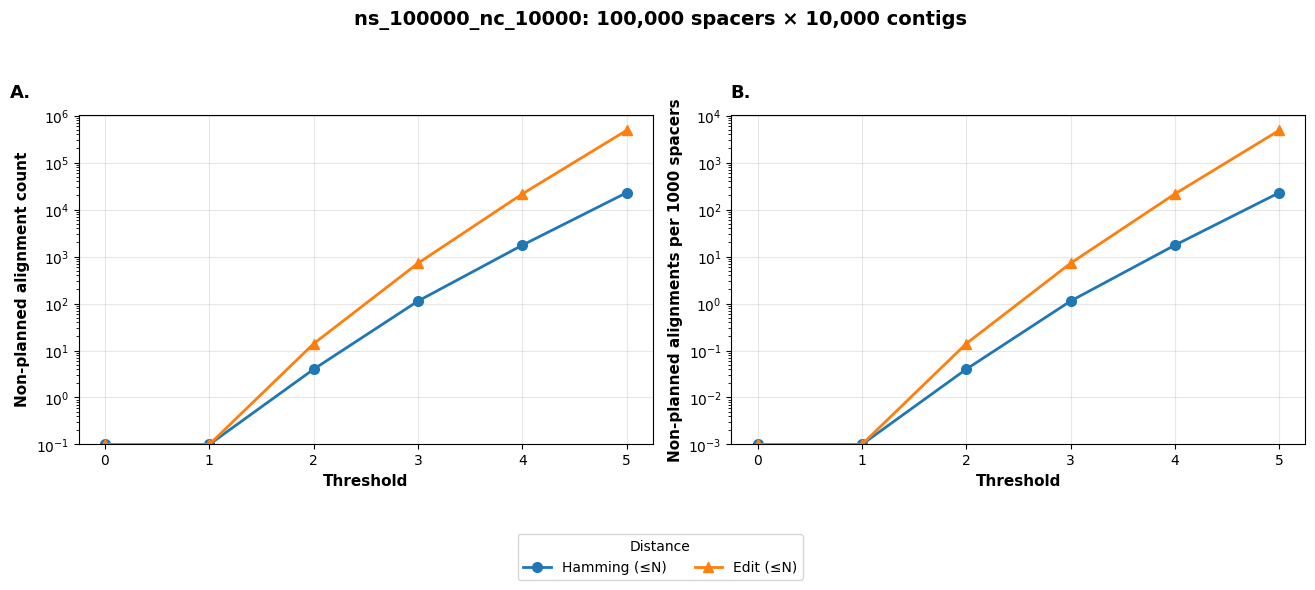

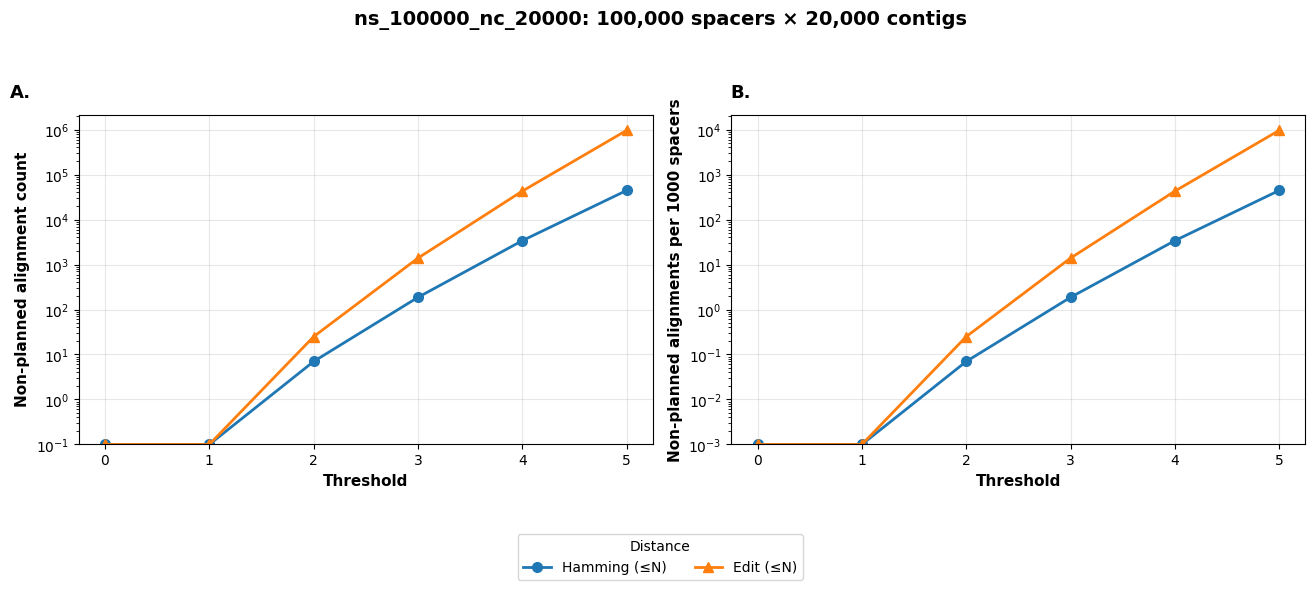

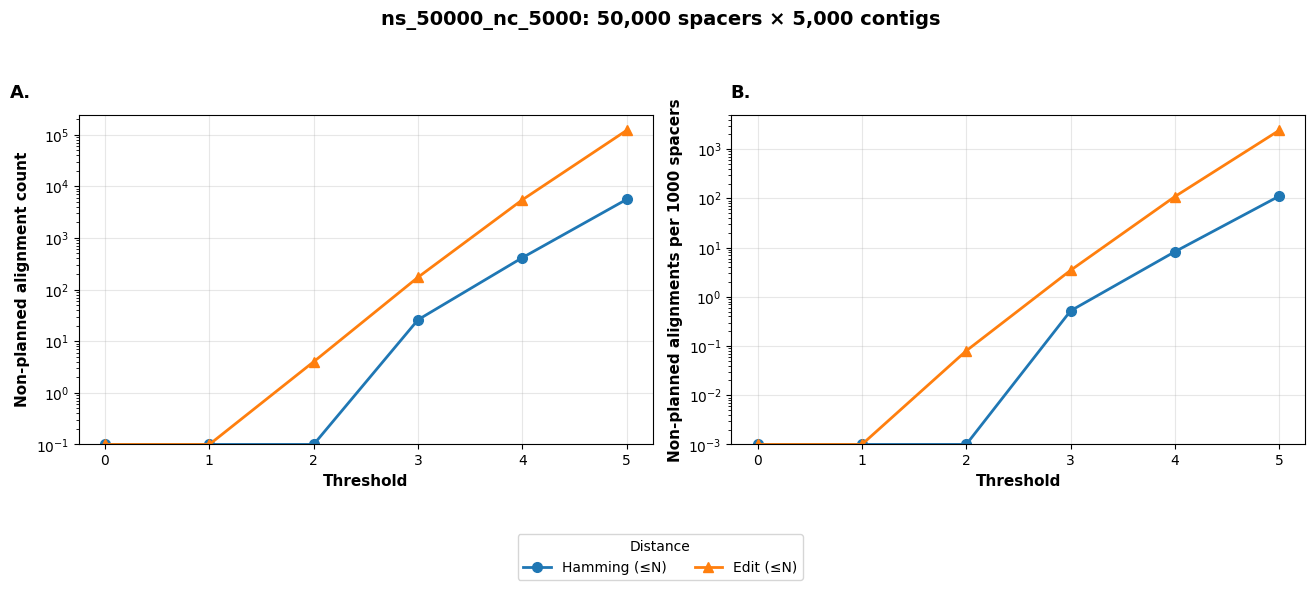

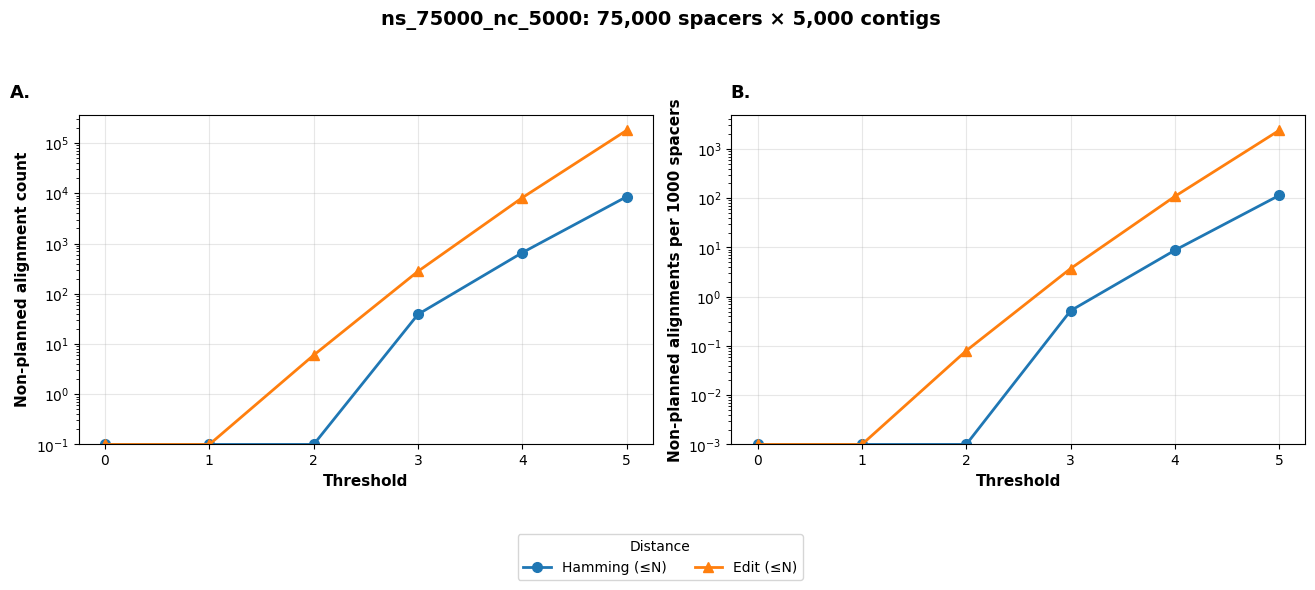

Saved per-simulation figures to draft/supp/figures (n=4)


In [161]:
# Per-simulation figures: 2x1 side-by-side layout (counts and per-1k) with readable titles
n_sims = len(all_results)
Path("draft/supp/figures").mkdir(parents=True, exist_ok=True)

for sim_name, results in all_results.items():
    parts = sim_name.split('_')
    try:
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])
    except (IndexError, ValueError):
        print(f"Skipping {sim_name}: cannot parse counts")
        continue

    hamming_counts = [results["hamming"][t]["n_non_planned"] for t in THRESHOLDS]
    edit_counts = [results["edit"][t]["n_non_planned"] for t in THRESHOLDS]
    hamming_per_1k = [(count / n_spacers) * 1000 for count in hamming_counts]
    edit_per_1k = [(count / n_spacers) * 1000 for count in edit_counts]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=False)

    # Absolute counts
    h_plot = [max(val, 0.1) for val in hamming_counts]
    e_plot = [max(val, 0.1) for val in edit_counts]
    ax1.plot(THRESHOLDS, h_plot, 'o-', linewidth=2, markersize=7, label='Hamming (≤N)', color='#1f77b4')
    ax1.plot(THRESHOLDS, e_plot, '^-', linewidth=2, markersize=7, label='Edit (≤N)', color='#ff7f0e')
    ax1.set_xlabel('Threshold', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Non-planned alignment count', fontsize=11, fontweight='bold')
    ax1.set_yscale('log')
    ax1.set_ylim(bottom=0.1)
    ax1.set_xticks(THRESHOLDS)
    ax1.grid(True, alpha=0.3)
    ax1.text(-0.12, 1.05, 'A.', transform=ax1.transAxes, fontsize=13, fontweight='bold')

    # Per 1000 spacers
    h_per1k_plot = [max(val, 0.001) for val in hamming_per_1k]
    e_per1k_plot = [max(val, 0.001) for val in edit_per_1k]
    ax2.plot(THRESHOLDS, h_per1k_plot, 'o-', linewidth=2, markersize=7, label='Hamming (≤N)', color='#1f77b4')
    ax2.plot(THRESHOLDS, e_per1k_plot, '^-', linewidth=2, markersize=7, label='Edit (≤N)', color='#ff7f0e')
    ax2.set_xlabel('Threshold', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Non-planned alignments per 1000 spacers', fontsize=11, fontweight='bold')
    ax2.set_xticks(THRESHOLDS)
    ax2.set_yscale('log')
    ax2.set_ylim(bottom=0.001)
    ax2.grid(True, alpha=0.3)
    ax2.text(-0.001, 1.05, 'B.', transform=ax2.transAxes, fontsize=13, fontweight='bold')

    # Increase spacing between the two panels
    fig.subplots_adjust(wspace=0.70)

    # Shared legend below to avoid title overlap and side whitespace
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend().remove()
    ax2.legend().remove()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.16),
               ncol=2, frameon=True, fontsize=10, title='Distance', title_fontsize=10)

    fig.suptitle(f"{sim_name}: {n_spacers:,} spacers × {n_contigs:,} contigs", fontsize=14, fontweight='bold', y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.91])

    outfile = Path("draft/supp/figures") / f"{sim_name}_background_counts_per1k.svg"
    fig.savefig(outfile, bbox_inches='tight')
    plt.show()

print(f"Saved per-simulation figures to draft/supp/figures (n={n_sims})")


Calculating aggregated metrics across all simulations...



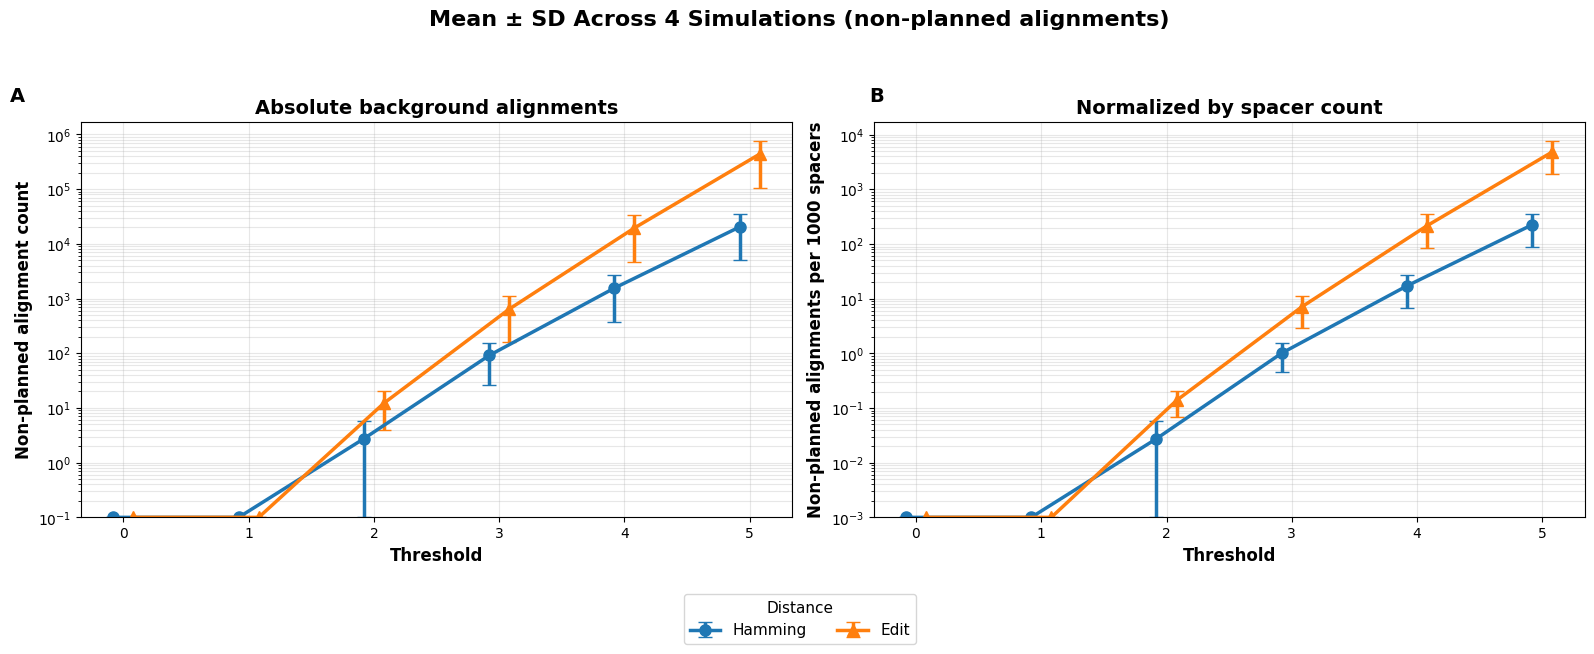

BACKGROUND ALIGNMENT SUMMARY (n=4 simulations)

Threshold ≤0:
  Hamming - Count:      0.0 ±    0.0  Per 1k:     0.00 ±   0.00
  Edit    - Count:      0.0 ±    0.0  Per 1k:     0.00 ±   0.00
  Ratio (Edit/Hamming):   0.0× count,   0.0× per 1k

Threshold ≤1:
  Hamming - Count:      0.0 ±    0.0  Per 1k:     0.00 ±   0.00
  Edit    - Count:      0.0 ±    0.0  Per 1k:     0.00 ±   0.00
  Ratio (Edit/Hamming):   0.0× count,   0.0× per 1k

Threshold ≤2:
  Hamming - Count:      2.8 ±    2.9  Per 1k:     0.03 ±   0.03
  Edit    - Count:     12.2 ±    8.3  Per 1k:     0.14 ±   0.07
  Ratio (Edit/Hamming):   4.5× count,   5.0× per 1k

Threshold ≤3:
  Hamming - Count:     91.2 ±   64.5  Per 1k:     1.01 ±   0.56
  Edit    - Count:    642.0 ±  479.9  Per 1k:     7.09 ±   4.22
  Ratio (Edit/Hamming):   7.0× count,   7.0× per 1k

Threshold ≤4:
  Hamming - Count:  1,556.8 ± 1,178.6  Per 1k:    17.15 ±  10.41
  Edit    - Count: 19,565.8 ± 14,835.2  Per 1k:   216.15 ± 130.83
  Ratio (Edit/Hamming):  12

In [162]:
# Create aggregated comparison plot with mean ± SD across all simulations
print("Calculating aggregated metrics across all simulations...\n")

# Collect data for each threshold across all simulations
hamming_counts_by_threshold = {t: [] for t in THRESHOLDS}
edit_counts_by_threshold = {t: [] for t in THRESHOLDS}
hamming_per_1k_by_threshold = {t: [] for t in THRESHOLDS}
edit_per_1k_by_threshold = {t: [] for t in THRESHOLDS}

for sim_name, results in all_results.items():
    # Parse simulation info
    parts = sim_name.split('_')
    try:
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])
    except (IndexError, ValueError):
        print(f"Warning: Could not parse {sim_name}, skipping")
        continue

    for t in THRESHOLDS:
        h = results["hamming"][t]
        e = results["edit"][t]

        hamming_counts_by_threshold[t].append(h["n_non_planned"])
        edit_counts_by_threshold[t].append(e["n_non_planned"])

        # Per 1000 spacers normalization
        hamming_per_1k_by_threshold[t].append((h["n_non_planned"] / n_spacers) * 1000)
        edit_per_1k_by_threshold[t].append((e["n_non_planned"] / n_spacers) * 1000)

# Calculate means and std
h_count_mean = [np.mean(hamming_counts_by_threshold[t]) for t in THRESHOLDS]
h_count_std = [np.std(hamming_counts_by_threshold[t]) for t in THRESHOLDS]
e_count_mean = [np.mean(edit_counts_by_threshold[t]) for t in THRESHOLDS]
e_count_std = [np.std(edit_counts_by_threshold[t]) for t in THRESHOLDS]

h_per1k_mean = [np.mean(hamming_per_1k_by_threshold[t]) for t in THRESHOLDS]
h_per1k_std = [np.std(hamming_per_1k_by_threshold[t]) for t in THRESHOLDS]
e_per1k_mean = [np.mean(edit_per_1k_by_threshold[t]) for t in THRESHOLDS]
e_per1k_std = [np.std(edit_per_1k_by_threshold[t]) for t in THRESHOLDS]

# Replace zeros with small values for log plotting (plotted values)
h_count_plot = [max(val, 0.1) for val in h_count_mean]
e_count_plot = [max(val, 0.1) for val in e_count_mean]
h_per1k_plot = [max(val, 0.001) for val in h_per1k_mean]
e_per1k_plot = [max(val, 0.001) for val in e_per1k_mean]

# Horizontal jitter to keep caps separated
offset = 0.08
x_h = [t - offset for t in THRESHOLDS]
x_e = [t + offset for t in THRESHOLDS]

# Clip lower error bars to the log floor so they never cross the axis
h_count_err_lower = [max(1e-9, min(h_count_std[i], h_count_plot[i] - 0.1)) for i in range(len(THRESHOLDS))]
e_count_err_lower = [max(1e-9, min(e_count_std[i], e_count_plot[i] - 0.1)) for i in range(len(THRESHOLDS))]
h_per1k_err_lower = [max(1e-9, min(h_per1k_std[i], h_per1k_plot[i] - 0.001)) for i in range(len(THRESHOLDS))]
e_per1k_err_lower = [max(1e-9, min(e_per1k_std[i], e_per1k_plot[i] - 0.001)) for i in range(len(THRESHOLDS))]

# Create 2 consolidated plots (v1 style with clipped lower whiskers and jittered x)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute counts
ax1.errorbar(x_h, h_count_plot, yerr=[h_count_err_lower, h_count_std],
             fmt='o-', linewidth=2.5, markersize=8, label='Hamming', color="#1f77b4", capsize=5)
ax1.errorbar(x_e, e_count_plot, yerr=[e_count_err_lower, e_count_std],
             fmt='^-', linewidth=2.5, markersize=8, label='Edit', color="#ff7f0e", capsize=5)
ax1.set_xlabel('Threshold', fontweight='bold', fontsize=12)
ax1.set_ylabel('Non-planned alignment count', fontweight='bold', fontsize=12)
ax1.set_title('Absolute background alignments', fontweight='bold', fontsize=14)
ax1.set_xticks(THRESHOLDS)
ax1.set_yscale('log')
ax1.set_ylim(bottom=0.1)
ax1.grid(True, alpha=0.3, which='both')
ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=14, fontweight='bold')

# Plot 2: Per 1000 spacers
ax2.errorbar(x_h, h_per1k_plot, yerr=[h_per1k_err_lower, h_per1k_std],
             fmt='o-', linewidth=2.5, markersize=8, label='Hamming', color="#1f77b4", capsize=5)
ax2.errorbar(x_e, e_per1k_plot, yerr=[e_per1k_err_lower, e_per1k_std],
             fmt='^-', linewidth=2.5, markersize=8, label='Edit', color="#ff7f0e", capsize=5)
ax2.set_xlabel('Threshold', fontweight='bold', fontsize=12)
ax2.set_ylabel('Non-planned alignments per 1000 spacers', fontweight='bold', fontsize=12)
ax2.set_title('Normalized by spacer count', fontweight='bold', fontsize=14)
ax2.set_xticks(THRESHOLDS)
ax2.set_yscale('log')
ax2.set_ylim(bottom=0.001)
ax2.grid(True, alpha=0.3, which='both')
ax2.text(-0.006, 1.05, 'B', transform=ax2.transAxes, fontsize=14, fontweight='bold')


# Increase spacing between side-by-side panels
fig.subplots_adjust(wspace=0.50)

# Shared legend below to avoid title overlap and side whitespace
handles, labels = ax1.get_legend_handles_labels()
ax1.legend().remove()
ax2.legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
           ncol=2, frameon=True, fontsize=11, title='Distance', title_fontsize=11)

plt.suptitle(f'Mean ± SD Across {len(all_results)} Simulations (non-planned alignments)',
            fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.91])

# Export SVG for manuscript
Path("draft/main/figures").mkdir(parents=True, exist_ok=True)
fig.savefig('draft/main/figures/background_alignment_hamming_vs_edit.svg', bbox_inches='tight')
plt.show()

# Save summary table for manuscript
summary_rows = []
for i, t in enumerate(THRESHOLDS):
    summary_rows.append({
        "threshold": t,
        "metric": "hamming",
        "count_mean": h_count_mean[i],
        "count_std": h_count_std[i],
        "per_1k_mean": h_per1k_mean[i],
        "per_1k_std": h_per1k_std[i]
    })
    summary_rows.append({
        "threshold": t,
        "metric": "edit",
        "count_mean": e_count_mean[i],
        "count_std": e_count_std[i],
        "per_1k_mean": e_per1k_mean[i],
        "per_1k_std": e_per1k_std[i]
    })
summary_df = pl.DataFrame(summary_rows)
Path("draft/main/figures/tables").mkdir(parents=True, exist_ok=True)
summary_df.write_csv("draft/main/figures/tables/background_alignment_summary.csv")

# Print summary statistics
print(f"BACKGROUND ALIGNMENT SUMMARY (n={len(all_results)} simulations)")
for t in THRESHOLDS:
    print(f"\nThreshold ≤{t}:")
    print(f"  Hamming - Count: {h_count_mean[t]:>8,.1f} ± {h_count_std[t]:>6,.1f}  Per 1k: {h_per1k_mean[t]:>8,.2f} ± {h_per1k_std[t]:>6,.2f}")
    print(f"  Edit    - Count: {e_count_mean[t]:>8,.1f} ± {e_count_std[t]:>6,.1f}  Per 1k: {e_per1k_mean[t]:>8,.2f} ± {e_per1k_std[t]:>6,.2f}")
    print(f"  Ratio (Edit/Hamming): {e_count_mean[t]/max(h_count_mean[t], 0.1):>5.1f}× count, {e_per1k_mean[t]/max(h_per1k_mean[t], 0.001):>5.1f}× per 1k")


## Search Space Analysis: Background Alignment Probability

The absolute count of non-planned alignments depends on the **search space size** (number of spacers × total contig length). To understand intrinsic background rates, we normalize by search space:

**Four normalization approaches:**
1. **Per million spacer bp**: `non-planned / (n_spacers × spacer_len / 1e6)`
2. **Per billion bp²**: `non-planned / (n_spacers × spacer_len × total_contig_len / 1e18)`
3. **Probability per spacer**: `non-planned / (n_spacers × total_contig_len)`
4. **Per 1000 spacers**: `non-planned / (n_spacers / 1000)`

These metrics help answer:
- Does the background rate scale linearly with search space?
- Are Edit distance background alignments more likely per unit search space?
- Can we predict background alignment counts for new datasets?

In [163]:
from bench.utils.functions import get_seq_stats_pl
all_seq_file_stat_dfs = []
search_space_data = []

for sim_name in all_results.keys():
    parts = sim_name.split('_')
    try:
        _ = int(parts[1])  # unused once we read true counts from files
        _ = int(parts[3])
    except (IndexError, ValueError):
        print(f"Warning: Could not parse {sim_name}, skipping")
        continue

    sims_spacers_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_spacers.fa")
    sims_contig_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_contigs.fa")
    if not (sims_contig_file.exists() and sims_spacers_file.exists()):
        print(f"Warning: Missing {sims_contig_file} or {sims_spacers_file} for {sim_name}, skipping")
        continue

    spacers_stats = get_seq_stats_pl(sims_spacers_file)
    contigs_stats = get_seq_stats_pl(sims_contig_file)
    all_seq_file_stat_dfs.extend([spacers_stats, contigs_stats])

    # Extract scalar stats
    spacer_bp = float(spacers_stats["sum_length"].item())
    contig_bp = float(contigs_stats["sum_length"].item())
    n_spacers = int(spacers_stats["n_seqs"].item())
    n_contigs = int(contigs_stats["n_seqs"].item())

    count_product = n_spacers * n_contigs
    length_product = spacer_bp * contig_bp

    hamming = all_results[sim_name]["hamming"][5]
    edit = all_results[sim_name]["edit"][5]

    for metric_name, results in [("Hamming", hamming), ("Edit", edit)]:
        n_non_planned = results["n_non_planned"]
        per_million_spacer_bp = n_non_planned / (spacer_bp / 1e6)
        per_billion_bp2 = n_non_planned / (length_product / 1e18)
        prob_per_spacer = n_non_planned / length_product
        per_1k_spacers = n_non_planned / (n_spacers / 1000)
        search_space_data.append({
            "simulation": sim_name,
            "metric": metric_name,
            "n_spacers": n_spacers,
            "n_contigs": n_contigs,
            "spacer_bp": spacer_bp,
            "contig_bp": contig_bp,
            "count_product": count_product,
            "length_product": length_product,
            "n_non_planned": n_non_planned,
            "non_planned_rate": results["non_planned_rate"],
            "per_million_spacer_bp": per_million_spacer_bp,
            "per_billion_bp2": per_billion_bp2,
            "prob_per_spacer": prob_per_spacer,
            "per_1k_spacers": per_1k_spacers
        })

In [164]:
# Convert to DataFrame
search_df = pl.DataFrame(search_space_data)
all_files_df = (
    pl.concat(all_seq_file_stat_dfs, how="vertical_relaxed")
    .with_columns(
        pl.col("file").cast(pl.Utf8),
        pl.when(pl.col("file").str.contains("spacers"))
         .then(pl.lit("spacers"))
         .when(pl.col("file").str.contains("contigs"))
         .then(pl.lit("contigs"))
         .otherwise(pl.lit(None))
         .alias("type"),
        pl.col("file").str.extract(r"results/simulated/([^/]+)/", group_index=1).alias("name"),
    )
 )
all_files_df.write_parquet("results/simulated/all_sequence_stats.parquet")

print(all_files_df)
print(f"Computed search space metrics for {len(search_space_data)} simulations × metrics")
print("\nFirst few rows:")
print(search_df.head(10))

shape: (8, 10)
┌──────────────────────────────────────────────────────────────────────────┬────────┬───────────────┬─────────────┬────────────┬────────────┬────────────┬──────────────┬─────────┬────────────────────┐
│ file                                                                     ┆ n_seqs ┆ median_length ┆ avg_length  ┆ sum_length ┆ min_length ┆ max_length ┆ gc_frac_mean ┆ type    ┆ name               │
│ ---                                                                      ┆ ---    ┆ ---           ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ ---          ┆ ---     ┆ ---                │
│ str                                                                      ┆ i32    ┆ f64           ┆ f64         ┆ i32        ┆ i32        ┆ i32        ┆ f64          ┆ str     ┆ str                │
╞══════════════════════════════════════════════════════════════════════════╪════════╪═══════════════╪═════════════╪════════════╪════════════╪════════════╪══════════════╪═════════╪══

 search space visualization


/tmp/ipykernel_78494/3763533926.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


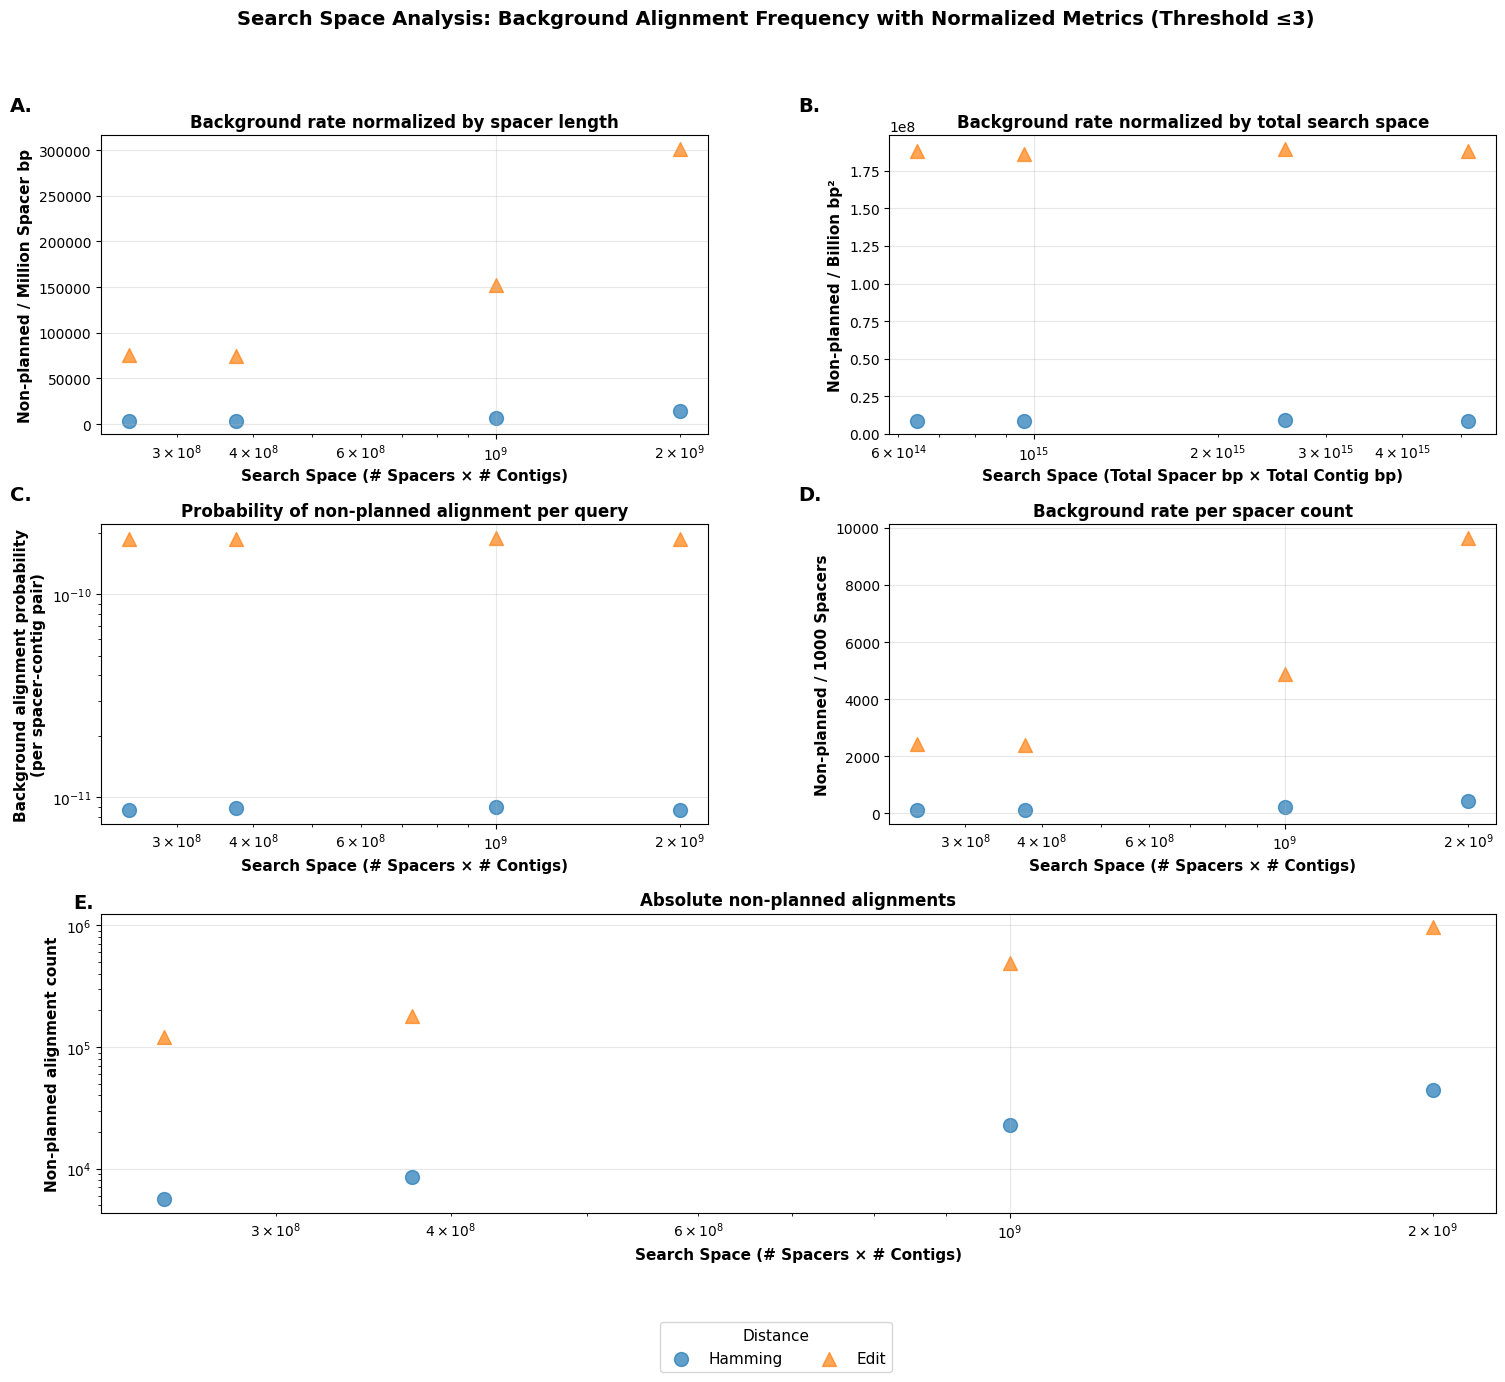

BACKGROUND NORMALIZATION SUMMARY (Threshold ≤3)

Per Million Spacer bp:
  Hamming - Mean: 7.04e+03  Median: 5.37e+03
  Edit    - Mean: 1.51e+05  Median: 1.14e+05
  Ratio (Edit/Hamming): 21.48×

Per Billion bp²:
  Hamming - Mean: 8.79e+06  Median: 8.79e+06
  Edit    - Mean: 1.88e+08  Median: 1.88e+08
  Ratio (Edit/Hamming): 21.39×

Probability per Spacer:
  Hamming - Mean: 8.79e-12  Median: 8.79e-12
  Edit    - Mean: 1.88e-10  Median: 1.88e-10
  Ratio (Edit/Hamming): 21.39×

Per 1000 Spacers:
  Hamming - Mean: 2.25e+02  Median: 1.72e+02
  Edit    - Mean: 4.84e+03  Median: 3.65e+03
  Ratio (Edit/Hamming): 21.48×

Absolute Count:
  Hamming - Mean: 2.04e+04  Median: 1.58e+04
  Edit    - Mean: 4.38e+05  Median: 3.34e+05
  Ratio (Edit/Hamming): 21.48×
CORRELATION ANALYSIS (Pearson)
Hamming per million spacer bp vs search space: 0.9966
Edit per million spacer bp vs search space: 0.9952
Hamming per billion bp² vs length product: -0.2684
Edit per billion bp² vs length product: 0.2788
Hamming pr

In [165]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Separate Hamming and Edit for plotting
hamming_df = search_df.filter(pl.col("metric") == "Hamming")
edit_df = search_df.filter(pl.col("metric") == "Edit")

count_products = hamming_df['count_product'].to_numpy()
length_products = hamming_df['length_product'].to_numpy()

panel_labels = ['A.', 'B.', 'C.', 'D.', 'E.']

# Plot 1: Background per million spacer bp vs count product
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(count_products, hamming_df['per_million_spacer_bp'].to_numpy(),
            s=100, alpha=0.7, label='Hamming', color='#1f77b4', marker='o')
ax1.scatter(count_products, edit_df['per_million_spacer_bp'].to_numpy(),
            s=100, alpha=0.7, label='Edit', color='#ff7f0e', marker='^')
ax1.set_xlabel('Search Space (# Spacers × # Contigs)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Non-planned / Million Spacer bp', fontweight='bold', fontsize=11)
ax1.set_title('Background rate normalized by spacer length', fontweight='bold', fontsize=12)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.text(-0.15, 1.08, panel_labels[0], transform=ax1.transAxes, fontsize=14, fontweight='bold')

# Plot 2: Background per billion bp² vs length product
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(length_products, hamming_df['per_billion_bp2'].to_numpy(),
            s=100, alpha=0.7, label='Hamming', color='#1f77b4', marker='o')
ax2.scatter(length_products, edit_df['per_billion_bp2'].to_numpy(),
            s=100, alpha=0.7, label='Edit', color='#ff7f0e', marker='^')
ax2.set_xlabel('Search Space (Total Spacer bp × Total Contig bp)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Non-planned / Billion bp²', fontweight='bold', fontsize=11)
ax2.set_title('Background rate normalized by total search space', fontweight='bold', fontsize=12)
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.text(-0.15, 1.08, panel_labels[1], transform=ax2.transAxes, fontsize=14, fontweight='bold')

# Plot 3: Background probability vs count product
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(count_products, hamming_df['prob_per_spacer'].to_numpy(),
            s=100, alpha=0.7, label='Hamming', color='#1f77b4', marker='o')
ax3.scatter(count_products, edit_df['prob_per_spacer'].to_numpy(),
            s=100, alpha=0.7, label='Edit', color='#ff7f0e', marker='^')
ax3.set_xlabel('Search Space (# Spacers × # Contigs)', fontweight='bold', fontsize=11)
ax3.set_ylabel('Background alignment probability\n(per spacer-contig pair)', fontweight='bold', fontsize=11)
ax3.set_title('Probability of non-planned alignment per query', fontweight='bold', fontsize=12)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
ax3.text(-0.15, 1.08, panel_labels[2], transform=ax3.transAxes, fontsize=14, fontweight='bold')

# Plot 4: Background per 1000 spacers vs count product
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(count_products, hamming_df['per_1k_spacers'].to_numpy(),
            s=100, alpha=0.7, label='Hamming', color='#1f77b4', marker='o')
ax4.scatter(count_products, edit_df['per_1k_spacers'].to_numpy(),
            s=100, alpha=0.7, label='Edit', color='#ff7f0e', marker='^')
ax4.set_xlabel('Search Space (# Spacers × # Contigs)', fontweight='bold', fontsize=11)
ax4.set_ylabel('Non-planned / 1000 Spacers', fontweight='bold', fontsize=11)
ax4.set_title('Background rate per spacer count', fontweight='bold', fontsize=12)
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)
ax4.text(-0.15, 1.08, panel_labels[3], transform=ax4.transAxes, fontsize=14, fontweight='bold')

# Plot 5: Absolute counts (for reference)
ax5 = fig.add_subplot(gs[2, :])
ax5.scatter(count_products, hamming_df['n_non_planned'].to_numpy(),
            s=100, alpha=0.7, label='Hamming', color='#1f77b4', marker='o')
ax5.scatter(count_products, edit_df['n_non_planned'].to_numpy(),
            s=100, alpha=0.7, label='Edit', color='#ff7f0e', marker='^')
ax5.set_xlabel('Search Space (# Spacers × # Contigs)', fontweight='bold', fontsize=11)
ax5.set_ylabel('Non-planned alignment count', fontweight='bold', fontsize=11)
ax5.set_title('Absolute non-planned alignments', fontweight='bold', fontsize=12)
ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.grid(True, alpha=0.3)
ax5.text(-0.02, 1.02, panel_labels[4], transform=ax5.transAxes, fontsize=14, fontweight='bold')

# Single shared legend below to avoid title overlap and side whitespace
handles, labels = ax1.get_legend_handles_labels()
for ax in (ax1, ax2, ax3, ax4, ax5):
    ax.legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.009),
           ncol=2, frameon=True, fontsize=11, title='Distance', title_fontsize=11)

plt.suptitle('Search Space Analysis: Background Alignment Frequency with Normalized Metrics (Threshold ≤3)',
             fontsize=14, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.90])

# Export SVG for manuscript
Path("draft/main/figures").mkdir(parents=True, exist_ok=True)
plt.savefig('draft/main/figures/search_space_background_normalization.svg', bbox_inches='tight')
plt.show()

# Save normalized metrics table
Path("draft/main/figures/tables").mkdir(parents=True, exist_ok=True)
search_df.write_csv('draft/main/figures/tables/search_space_normalized_metrics.csv')

# Print summary statistics

print("BACKGROUND NORMALIZATION SUMMARY (Threshold ≤3)")

metrics_summary = [
    ("per_million_spacer_bp", "Per Million Spacer bp"),
    ("per_billion_bp2", "Per Billion bp²"),
    ("prob_per_spacer", "Probability per Spacer"),
    ("per_1k_spacers", "Per 1000 Spacers"),
    ("n_non_planned", "Absolute Count")
]

for col, title in metrics_summary:
    hamming_vals = hamming_df[col].to_numpy()
    edit_vals = edit_df[col].to_numpy()

    print(f"\n{title}:")
    print(f"  Hamming - Mean: {hamming_vals.mean():.2e}  Median: {np.median(hamming_vals):.2e}")
    print(f"  Edit    - Mean: {edit_vals.mean():.2e}  Median: {np.median(edit_vals):.2e}")
    print(f"  Ratio (Edit/Hamming): {edit_vals.mean() / hamming_vals.mean():.2f}×")

# Calculate correlations

print("CORRELATION ANALYSIS (Pearson)")
print(f"Hamming per million spacer bp vs search space: {np.corrcoef(count_products, hamming_df['per_million_spacer_bp'].to_numpy())[0, 1]:.4f}")
print(f"Edit per million spacer bp vs search space: {np.corrcoef(count_products, edit_df['per_million_spacer_bp'].to_numpy())[0, 1]:.4f}")
print(f"Hamming per billion bp² vs length product: {np.corrcoef(length_products, hamming_df['per_billion_bp2'].to_numpy())[0, 1]:.4f}")
print(f"Edit per billion bp² vs length product: {np.corrcoef(length_products, edit_df['per_billion_bp2'].to_numpy())[0, 1]:.4f}")
print(f"Hamming probability vs search space: {np.corrcoef(count_products, hamming_df['prob_per_spacer'].to_numpy())[0, 1]:.4f}")
print(f"Edit probability vs search space: {np.corrcoef(count_products, edit_df['prob_per_spacer'].to_numpy())[0, 1]:.4f}")


## Interpretation of Normalized Metrics

The normalized metrics (per million spacer bp, per billion bp², probability, per 1k spacers) are **INDEPENDENT** of how many planned insertions we made in the simulation.

**Best metric depends on the question:**
- **Per million spacer bp**: How often per unit of query sequence? (assumes spacer length distribution is similar to real data and sample-able)
- **Per billion bp²**: How often per unit of search space? (total spacer bp × total contig bp)
- **Probability per spacer**: What's the chance for any given spacer-contig pair?
- **Per 1k spacers**: Expected non-planned matches per 1000 queries? (probably the most intuitive)

**NOTE**: These metrics assume that spacers and contigs simulated are fairly "true to life" in terms of sequence complexity and repetitiveness. Moreover, the "n per x" normalization assumes xs and ns are populations allowing for scaling/sampling that support extrapolations. 

In our case:
- Most spacer lengths are in a fairly narrow range (20-40 bp) with a normal/close-to-normal distribution
- Contig lengths are more variable - we matched the distribution to real HQ IMG/VR4 data
- For researchers working on more localized datasets (e.g., single genome, small set of related genomes, or metagenome from the same source), sequence complexity and repetitiveness may differ significantly, affecting non-planned match rates

**That said**, these metrics should still be informative in a **comparative manner** (i.e., Hamming vs Edit distance and to what degree), as they use the same underlying data.

In [166]:
# Calculate all four normalized metrics (threshold = 3) without re-reading FASTA files
# Reuse sequence stats already computed earlier from raw FASTA (search_df)

search_space_data = []

# Build a lookup of sequence stats per simulation using the existing search_df (Hamming rows carry the scalars)
seq_df = search_df.filter(pl.col("metric") == "Hamming")
if "spacer_bp" not in seq_df.columns:  # backward-compatible with total_* naming
    seq_df = seq_df.rename({"total_spacer_len": "spacer_bp", "total_contig_len": "contig_bp"})

stats_lookup = {
    row["simulation"]: {
        "n_spacers": row["n_spacers"],
        "n_contigs": row["n_contigs"],
        "spacer_bp": row["spacer_bp"],
        "contig_bp": row["contig_bp"],
        "count_product": row["count_product"],
        "length_product": row["length_product"],
    }
    for row in seq_df.select(
        "simulation", "n_spacers", "n_contigs", "spacer_bp", "contig_bp", "count_product", "length_product"
    ).to_dicts()
}

for sim_name, results in all_results.items():
    meta = stats_lookup.get(sim_name)
    if meta is None:
        print(f"Warning: Missing precomputed stats for {sim_name}, skipping")
        continue

    n_spacers = meta["n_spacers"]
    n_contigs = meta["n_contigs"]
    spacer_bp = meta["spacer_bp"]
    contig_bp = meta["contig_bp"]
    count_product = meta["count_product"]
    length_product = meta["length_product"]

    # Use threshold = 3 for both metrics
    hamming = all_results[sim_name]["hamming"].get(3)
    edit = all_results[sim_name]["edit"].get(3)
    if hamming is None or edit is None:
        print(f"Warning: Missing threshold 3 results for {sim_name}, skipping")
        continue

    for metric_name, metric_results in [("Hamming", hamming), ("Edit", edit)]:
        n_non_planned = metric_results["n_non_planned"]

        # Search space normalizations (matching previous notebook formulas)
        per_million_spacer_bp = n_non_planned / (spacer_bp / 1e6)
        per_billion_bp2 = n_non_planned / (spacer_bp * contig_bp / 1e18)
        prob_per_spacer = n_non_planned / (n_spacers * contig_bp)
        per_1k_spacers = n_non_planned / (n_spacers / 1000)

        search_space_data.append({
            "simulation": sim_name,
            "metric": metric_name,
            "n_spacers": n_spacers,
            "n_contigs": n_contigs,
            "total_spacer_len": spacer_bp,
            "total_contig_len": contig_bp,
            "count_product": count_product,
            "length_product": length_product,
            "n_non_planned": n_non_planned,
            "per_million_spacer_bp": per_million_spacer_bp,
            "per_billion_bp2": per_billion_bp2,
            "prob_per_spacer": prob_per_spacer,
            "per_1k_spacers": per_1k_spacers,
        })

# Convert to DataFrame and save to supplementary tables
search_df = pl.DataFrame(search_space_data)
Path("draft/supp/figures/tables").mkdir(parents=True, exist_ok=True)
search_df.write_csv("draft/supp/figures/tables/search_space_normalized_metrics_threshold3.csv")

print(f"Computed search space metrics for {len(search_space_data)} simulation-metric combinations")
print(f"({len(search_space_data)//2} simulations \u00d7 2 metrics)")
print("Saved table to draft/supp/figures/tables/search_space_normalized_metrics_threshold3.csv")
print(search_df)


Computed search space metrics for 8 simulation-metric combinations
(4 simulations × 2 metrics)
Saved table to draft/supp/figures/tables/search_space_normalized_metrics_threshold3.csv
shape: (8, 13)
┌────────────────────┬─────────┬───────────┬───────────┬──────────────────┬──────────────────┬───────────────┬────────────────┬───────────────┬───────────────────────┬─────────────────┬─────────────────┬────────────────┐
│ simulation         ┆ metric  ┆ n_spacers ┆ n_contigs ┆ total_spacer_len ┆ total_contig_len ┆ count_product ┆ length_product ┆ n_non_planned ┆ per_million_spacer_bp ┆ per_billion_bp2 ┆ prob_per_spacer ┆ per_1k_spacers │
│ ---                ┆ ---     ┆ ---       ┆ ---       ┆ ---              ┆ ---              ┆ ---           ┆ ---            ┆ ---           ┆ ---                   ┆ ---             ┆ ---             ┆ ---            │
│ str                ┆ str     ┆ i64       ┆ i64       ┆ f64              ┆ f64              ┆ i64           ┆ f64            ┆ i64        

## Semi-Synthetic Dataset Analysis

The semi-synthetic dataset uses **real CRISPR spacers** from IMG/VR4 searched against **real viral contigs**. This provides:

- **Realistic base composition** (not uniform random)
- **Real sequence complexity** (repeats, low-complexity regions, etc.)
- **No planned insertions** - all matches are non-planned/chance matches
- **Large-scale testing** (~3.8M spacers × 421K contigs)

This is the closest approximation to real-world non-planned match rates.

**IMPORTANT**: For this dataset, we could only run **non-exhaustive gapless tools** (Hamming distance only). The exhaustive edit distance tool (sassy) is too compute-intensive for this large search space.

Key questions:
- Do non-planned frequencies differ from pure simulations?

- How do the normalized metrics compare?- Can we predict non-planned match counts for similar real-world datasets?

In [167]:
# Analyze semi-synthetic dataset(s) - HAMMING ONLY
if len(semisynthetic_sims) == 0:
    print("No semi-synthetic simulations found!")
else:
    semisynthetic_results = {}
    
    print(f"Processing {len(semisynthetic_sims)} semi-synthetic dataset(s)...\n")
    print("NOTE: Only analyzing Hamming distance (gapless tools).")
    print("      Edit distance tools (sassy) are too compute-intensive for this dataset.\n")
    
    for sim_dir in semisynthetic_sims:
        print(f"Processing {sim_dir.name}...")
        try:
            results = analyze_simulation_multi_metric(
                sim_dir,
                metrics=["hamming"],  # ONLY Hamming for semi-synthetic
                force_regenerate=False
            )
            semisynthetic_results[sim_dir.name] = results
            print(f"  ✓ Complete\n")
        except Exception as e:
            print(f"  ✗ ERROR: {e}\n")
            continue

        print(f"Successfully analyzed {len(semisynthetic_results)} semi-synthetic dataset(s)")

Processing 1 semi-synthetic dataset(s)...

NOTE: Only analyzing Hamming distance (gapless tools).
      Edit distance tools (sassy) are too compute-intensive for this dataset.

Processing ns_3826979_nc_421431_real_baseline...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Successfully analyzed 1 semi-synthetic dataset(s)


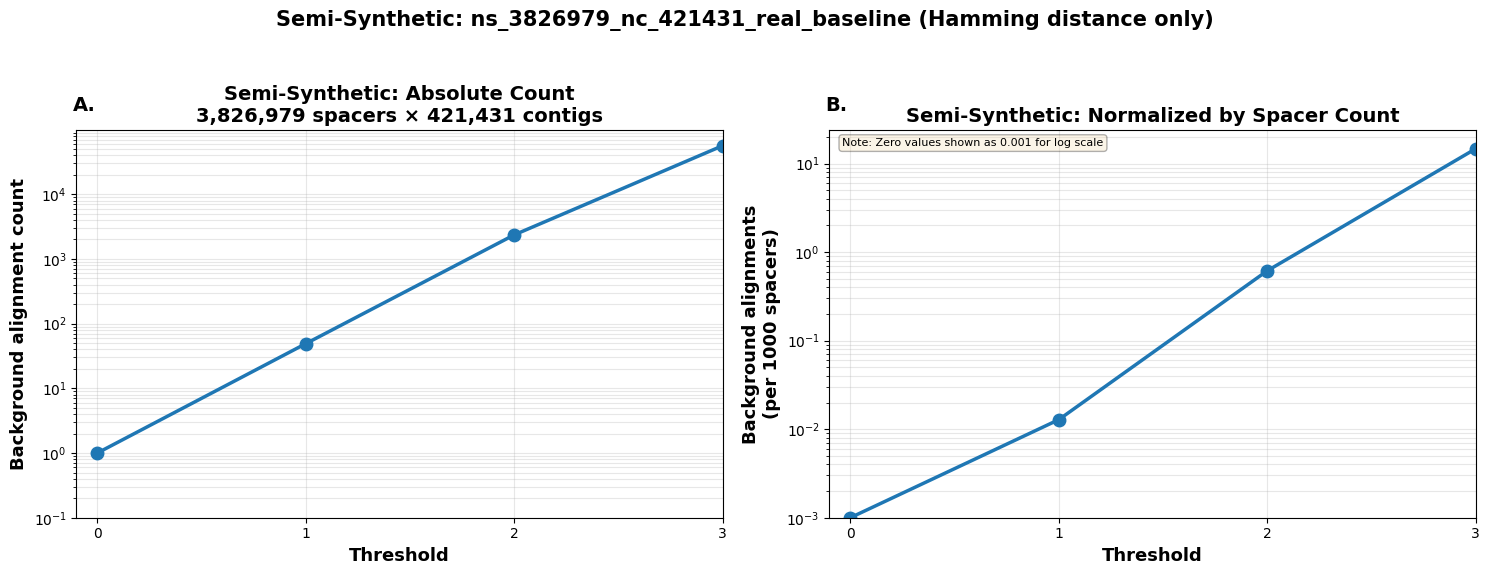

SEMI-SYNTHETIC DATASET STATISTICS (Hamming only)

ns_3826979_nc_421431_real_baseline:
Search space: 3,826,979 spacers × 421,431 contigs

Threshold    Non-planned Count  Per 1k Spacers    
≤0           1                  0.00              
≤1           49                 0.01              
≤2           2,354              0.62              
≤3           56,273             14.70             
≤4           72,132             18.85             
≤5           113,314            29.61             
COMPARISON: Semi-Synthetic vs Simulated Data Average
≤0           Semi-syn:     0.00  Simulated avg:     0.00  Ratio:  0.26×
≤1           Semi-syn:     0.01  Simulated avg:     0.00  Ratio: 12.80×
≤2           Semi-syn:     0.62  Simulated avg:     0.03  Ratio: 22.37×
≤3           Semi-syn:    14.70  Simulated avg:     1.01  Ratio: 14.56×
≤4           Semi-syn:    18.85  Simulated avg:    17.15  Ratio:  1.10×
≤5           Semi-syn:    29.61  Simulated avg:   225.21  Ratio:  0.13×


In [168]:
# Plot semi-synthetic results (HAMMING ONLY)
if len(semisynthetic_results) > 0:
    for sim_name, results in semisynthetic_results.items():
        # Parse simulation info
        parts = sim_name.split('_')
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])

        # Extract metrics
        hamming_counts = [results["hamming"][t]["n_non_planned"] for t in THRESHOLDS]
        hamming_per_1k = [(count / n_spacers) * 1000 for count in hamming_counts]

        # Thresholds to display (hide >3.5)
        plot_thresholds = [t for t in THRESHOLDS if t <= 3.5]

        # Create plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Plot 1: Absolute counts (only up to 3.5)
        counts_plot = [max(val, 0.1) for val in hamming_counts]
        counts_plot_visible = [counts_plot[i] for i, t in enumerate(THRESHOLDS) if t <= 3.5]
        ax1.plot(plot_thresholds, counts_plot_visible, 'o-', label='Hamming (≤N)',
                 color='#1f77b4', linewidth=2.5, markersize=9)
        ax1.set_xlabel('Threshold', fontweight='bold', fontsize=13)
        ax1.set_ylabel('Background alignment count', fontweight='bold', fontsize=13)
        ax1.set_title(f'Semi-Synthetic: Absolute Count\n{n_spacers:,} spacers × {n_contigs:,} contigs',
                      fontweight='bold', fontsize=14)
        ax1.set_xticks(plot_thresholds)
        ax1.set_xticklabels([str(t) for t in plot_thresholds])
        ax1.set_xlim(-0.1, max(plot_thresholds) if plot_thresholds else 3.5)
        ax1.set_yscale('log')
        ax1.set_ylim(bottom=0.1)
        ax1.grid(True, alpha=0.3, which='both')
        ax1.text(-0.006, 1.05, 'A.', transform=ax1.transAxes, fontsize=14, fontweight='bold')
        # Plot 2: Per 1000 spacers (only up to 3.5)
        per1k_plot = [max(val, 0.001) for val in hamming_per_1k]
        per1k_plot_visible = [per1k_plot[i] for i, t in enumerate(THRESHOLDS) if t <= 3.5]
        ax2.plot(plot_thresholds, per1k_plot_visible, 'o-', label='Hamming (≤N)',
                 color='#1f77b4', linewidth=2.5, markersize=9)
        ax2.set_xlabel('Threshold', fontweight='bold', fontsize=13)
        ax2.set_ylabel('Background alignments\n(per 1000 spacers)', fontweight='bold', fontsize=13)
        ax2.set_title('Semi-Synthetic: Normalized by Spacer Count',
                      fontweight='bold', fontsize=14)
        ax2.set_xticks(plot_thresholds)
        ax2.set_xticklabels([str(t) for t in plot_thresholds])
        ax2.set_xlim(-0.1, max(plot_thresholds) if plot_thresholds else 3.5)
        ax2.set_yscale('log')
        ax2.set_ylim(bottom=0.001)
        ax2.grid(True, alpha=0.3, which='both')
        ax2.text(-0.006, 1.05, 'B.', transform=ax2.transAxes, fontsize=14, fontweight='bold')
        ax2.text(0.02, 0.98, 'Note: Zero values shown as 0.001 for log scale',
                 transform=ax2.transAxes, fontsize=8, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        # Increase spacing between panels
        fig.subplots_adjust(wspace=0.70)

        # Single shared legend below to avoid title overlap and side whitespace
        handles, labels = ax1.get_legend_handles_labels()
        ax1.legend().remove()
        ax2.legend().remove()
        # fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.10),
        #            ncol=2, frameon=True, fontsize=12, title='Distance', title_fontsize=12)

        plt.suptitle(f'Semi-Synthetic: {sim_name} (Hamming distance only)',
                     fontsize=15, fontweight='bold', y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.91])

        # Export SVG for supplementary
        Path("draft/supp/figures").mkdir(parents=True, exist_ok=True)
        fig.savefig(f'draft/supp/figures/{sim_name}_hamming_background.svg', bbox_inches='tight')
        plt.show()

        # Save table for supplementary
        table_rows = []
        for i, t in enumerate(THRESHOLDS):
            table_rows.append({
                "threshold": t,
                "n_non_planned": hamming_counts[i],
                "per_1k_spacers": hamming_per_1k[i]
            })
        Path("draft/supp/figures/tables").mkdir(parents=True, exist_ok=True)
        pl.DataFrame(table_rows).write_csv(f'draft/supp/figures/tables/{sim_name}_hamming_background.csv')

        # Print detailed statistics
        print("SEMI-SYNTHETIC DATASET STATISTICS (Hamming only)")
        print(f"\n{sim_name}:")
        print(f"Search space: {n_spacers:,} spacers × {n_contigs:,} contigs")

        print(f"\n{'Threshold':<12} {'Non-planned Count':<18} {'Per 1k Spacers':<18}")
        for t in THRESHOLDS:
            hamming = results["hamming"][t]
            print(f"≤{t:<11} {hamming['n_non_planned']:<18,} {hamming_per_1k[t]:<18.2f}")

        # Compare with simulated data averages
        print("COMPARISON: Semi-Synthetic vs Simulated Data Average")
        for t in THRESHOLDS:
            semisyn_per1k = hamming_per_1k[t]
            simu_per1k_avg = h_per1k_mean[t]  # From aggregated simulations
            ratio = semisyn_per1k / max(simu_per1k_avg, 0.001)
            print(f"≤{t:<11} Semi-syn: {semisyn_per1k:>8.2f}  Simulated avg: {simu_per1k_avg:>8.2f}  Ratio: {ratio:>5.2f}×")

else:
    print("No semi-synthetic results to plot")


## Summary
   - Edit distance consistently produces more background (non-planned) matches (10-100× higher)
   - Both scale with threshold
   - Normalized metrics suggest the scaling seems consistent, but it is likely too run specific.
   - **Absolute counts**: probably the most useful, specifically in the semi-synthetic dataset.
   - **Per 1000 spacers**: ~0.5-5 for Hamming ≤3, ~50-500 for Edit ≤3. This is specific for a given dataset (contigs) size and compositions.
   - **Per million spacer bp**: Normalizes for sequence length
   - **Per billion bp²**: Normalizes for total search space (might be the most useful, even if aggressively simplified).
   - Normalized metrics remain *****relatively***** stable across simulations, or at least within the same order of magnitude per metric per threshold.
## Semi-Synthetic vs Purely Simulated Datasets
   - Larger dataset (~3.8M spacers × 421K contigs)
   - Real base composition and complexity (IMG/VR4 data)
   - **Higher non-planned match rates**

### Notes:
   - Currently, no simulation has indel mutations. We added this functionality for future sake. 
   - We could only test hamming<=3 for the semi-synthetic dataset as it was too large for the exhaustive and edit-based tools. The values >3 should not be taken seriously.
   